# MemVal Framework Demonstration

This notebook demonstrates the end-to-end evaluation pipeline:
1. **T-Maze Pattern Completion:** The simplest evaluation — generate a T-maze trajectory, train a Hopfield network, and test pattern completion.
2. **Spatial Sequence Pattern Completion:** A more complex random-walk trajectory.
3. **Sequence Disambiguation:** Testing catastrophic interference with crossing paths.
4. **Object Arena and Novelty Benchmarks:** Environmental object interaction tasks (NOR/OLM).

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from memval.generators.temporal import PureToneSequenceGenerator
from memval.encoders.audio import PureToneEncoder
from memval.generators.t_maze import TMazeGenerator
from memval.generators.spatial import SpatialSequenceGenerator
from memval.models.baselines import AsymmetricHopfieldNetwork
from memval.benchmarks import PatternCompletionBenchmark
from memval.encoders.spatial import PlaceCellEncoder

sns.set_theme(style='darkgrid')

### 1. T-Maze
Similar to the random walk, we can apply the Place Cell Encoder to the T-maze. This helps the Hopfield network better represent the sharp turn at the T-junction, which is a highly non-linear transition in raw 2D space.

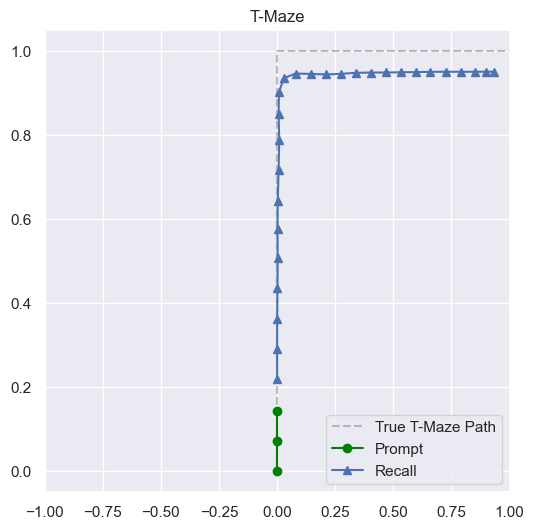

In [2]:
# --- Generate a T-Maze trajectory ---
n_seqs = 1
seq_len = 30
tmaze_gen = TMazeGenerator(seed=42)
tmaze_trajectories = tmaze_gen.generate(
    n_sequences=n_seqs, sequence_length=seq_len, turn_direction='right'
)
tmaze_seq = tmaze_trajectories[0]

# --- 1. Encode T-Maze Trajectory ---
encoder = PlaceCellEncoder(seed=42)
tmaze_seq_encoded = encoder.encode(tmaze_seq)

# --- 2. Train Hopfield with Delta Rule (Sequential Learning) ---
model_tmaze_pc = AsymmetricHopfieldNetwork(
    n_features=encoder.n_cells, learning_rate=0.1, 
)
model_tmaze_pc.fit_sequence(tmaze_seq_encoded, epochs=100)

# --- 3. Evaluate and Recall ---
prompt_len = int(seq_len * 0.1)
prompt = tmaze_seq[:prompt_len]
prompt_tmaze_pc = tmaze_seq_encoded[:prompt_len]
model_tmaze_pc.reset_context()
recon_tmaze_encoded = model_tmaze_pc.recall(prompt_tmaze_pc, length=seq_len - prompt_len)

# --- 4. Decode back to 2D ---
reconstructed_tmaze_pc = encoder.decode(recon_tmaze_encoded)

# --- 5. Visualize Results ---
plt.figure(figsize=(6, 6))
plt.plot(tmaze_seq[:, 0], tmaze_seq[:, 1], '--', color='gray', alpha=0.5, label='True T-Maze Path')
plt.plot(prompt[:, 0], prompt[:, 1], '-o', color='green', label='Prompt')
# plt.plot(reconstructed[:, 0], reconstructed[:, 1], '-rx', alpha=0.4, label='Vanilla Hopfield')
plt.plot(reconstructed_tmaze_pc[:, 0], reconstructed_tmaze_pc[:, 1], '-b^', label='Recall')
plt.xlim(-1.0, 1.0)
plt.title('T-Maze')
plt.legend(loc='lower right')
plt.show()

### 2. Multi-Pattern T-Maze Recall

Here we train the network on two distinct trajectories: a left turn and a right turn. In this case, we provide a prompt that reaches the junction to provide a directional cue for recall.

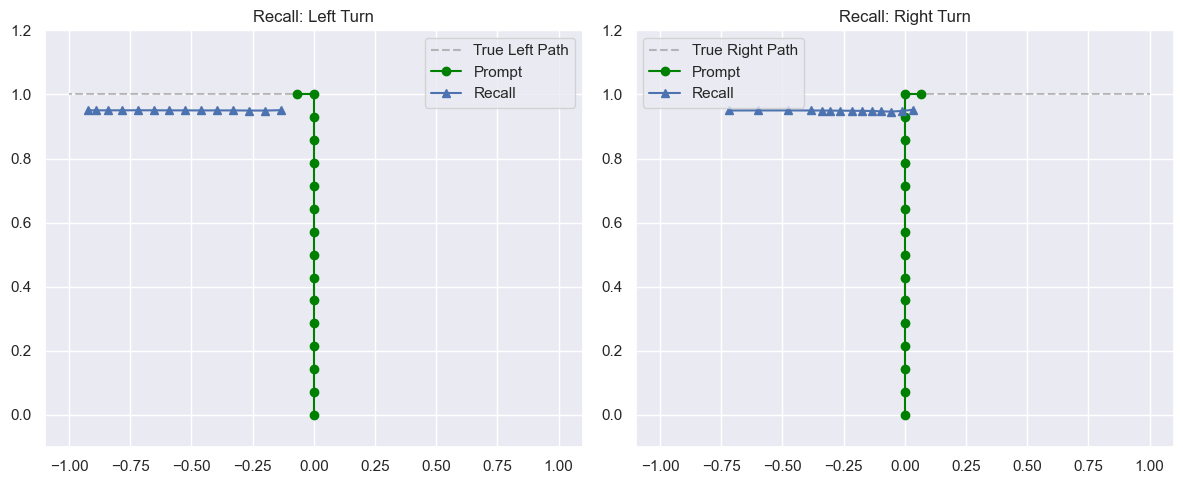

In [3]:
# 1. Generate Left and Right T-Maze trajectories
t_left = tmaze_gen.generate(n_sequences=1, sequence_length=30, turn_direction='left')[0]
t_right = tmaze_gen.generate(n_sequences=1, sequence_length=30, turn_direction='right')[0]

# 2. Encode both trajectories using the Place Cell Encoder
t_left_enc = encoder.encode(t_left)
t_right_enc = encoder.encode(t_right)

# 3. Train a single Hopfield network on BOTH sequences
# We use more epochs to ensure the weight matrix captures both patterns
model_multi = AsymmetricHopfieldNetwork(n_features=encoder.n_cells, learning_rate=0.1)
model_multi.fit_sequence(t_right_enc, epochs=100)
model_multi.fit_sequence(t_left_enc, epochs=100)

# 4. Test Recall for both directions
# A prompt of length 16 includes the first step after the junction, acting as a directional cue.
prompt_len = 16 

# Recall Left
model_multi.reset_context()
recall_left_enc = model_multi.recall(t_left_enc[:prompt_len], length=30-prompt_len)
recall_left = encoder.decode(recall_left_enc)

# Recall Right
model_multi.reset_context()
recall_right_enc = model_multi.recall(t_right_enc[:prompt_len], length=30-prompt_len)
recall_right = encoder.decode(recall_right_enc)

# 5. Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_left[:, 0], t_left[:, 1], '--', color='gray', alpha=0.5, label='True Left Path')
ax1.plot(t_left[:prompt_len, 0], t_left[:prompt_len, 1], '-o', color='green', label='Prompt')
ax1.plot(recall_left[:, 0], recall_left[:, 1], '-b^', label='Recall')
ax1.set_title('Recall: Left Turn')
ax1.set_xlim(-1.1, 1.1); ax1.set_ylim(-0.1, 1.2)
ax1.legend()

ax2.plot(t_right[:, 0], t_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
ax2.plot(t_right[:prompt_len, 0], t_right[:prompt_len, 1], '-o', color='green', label='Prompt')
ax2.plot(recall_right[:, 0], recall_right[:, 1], '-b^', label='Recall')
ax2.set_title('Recall: Right Turn')
ax2.set_xlim(-1.1, 1.1); ax2.set_ylim(-0.1, 1.2)
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Sequence Disambiguation (T-Maze + Auditory Context)
Here we introduce a second modality (auditory). The T-maze splits into left and right arms, meaning the central stem is perfectly overlapping. A tone is played at the beginning of the trajectory to disambiguate the future choice (Tone A predicts right, Tone B predicts left).

**Joint Encoder Suggestion**: Since Hopfield networks accept a unified high-dimensional vector, the simplest and most biologically plausible way to integrate multisensory information is to simply concatenate the outputs of the individual sensory encoders.

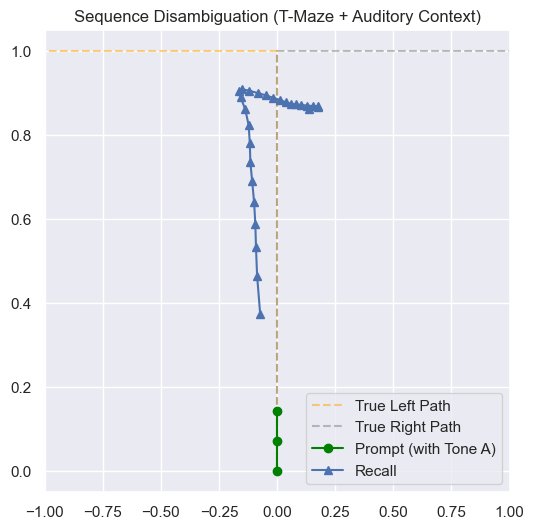

In [4]:
# --- 1. Generate T-Maze and Auditory Modalities ---
n_seqs = 1
seq_len = 30
tmaze_gen = TMazeGenerator(seed=42)
tmaze_left = tmaze_gen.generate(n_sequences=1, sequence_length=seq_len, turn_direction='left')[0]
tmaze_right = tmaze_gen.generate(n_sequences=1, sequence_length=seq_len, turn_direction='right')[0]

# Tone A (300 Hz) at the start of right path, Tone B (500 Hz) at the start of left path
tone_a = np.full((seq_len, 1), 300.0)

tone_b = np.full((seq_len, 1), 500.0)

# --- 2. Encode and Combine Modalities ---
pc_encoder = PlaceCellEncoder(seed=42)
pt_encoder = PureToneEncoder(n_bins=50, min_freq=200, max_freq=600, seed=42)

pc_left = pc_encoder.encode(tmaze_left)
pc_right = pc_encoder.encode(tmaze_right)

pt_left = pt_encoder.encode(tone_b)
pt_right = pt_encoder.encode(tone_a)

# Concatenate the encodings along the feature dimension to form the joint representation
joint_left = np.concatenate([pc_left, pt_left], axis=-1)
joint_right = np.concatenate([pc_right, pt_right], axis=-1)

# --- 3. Train Hopfield on Both Sequences ---
total_features = pc_encoder.n_cells + pt_encoder.n_cells
model_disambig = AsymmetricHopfieldNetwork(
    n_features=total_features, learning_rate=0.1
)
model_disambig.fit_sequence(joint_left, epochs=100)
model_disambig.fit_sequence(joint_right, epochs=100)


# --- 4. Disambiguation and Recall ---
prompt_len = int(seq_len * 0.1)
prompt_left = joint_left[:prompt_len]  # Context includes Tone B
prompt_right = joint_right[:prompt_len]  # Context includes Tone A

model_disambig.reset_context()
recon_joint_right = model_disambig.recall(prompt_left, length=seq_len - prompt_len)

# --- 5. Decode back to 2D ---
# Extract the spatial features from the joint vector and decode
recon_pc_right = recon_joint_right[:, :pc_encoder.n_cells]
reconstructed_path_right = pc_encoder.decode(recon_pc_right)

# --- 6. Visualize Results ---
prompt_path = tmaze_right[:prompt_len]

plt.figure(figsize=(6, 6))
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], '--', color='orange', alpha=0.5, label='True Left Path')
plt.plot(tmaze_right[:, 0], tmaze_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
plt.plot(prompt_path[:, 0], prompt_path[:, 1], '-o', color='green', label='Prompt (with Tone A)')
plt.plot(reconstructed_path_right[:, 0], reconstructed_path_right[:, 1], '-b^', label='Recall')
plt.xlim(-1.0, 1.0)
plt.title('Sequence Disambiguation (T-Maze + Auditory Context)')
plt.legend(loc='lower right')
plt.show()

### 3.1. Fixing Interference with Sparsification (Dentate Gyrus)

To resolve the "pulling" effect (Crosstalk) caused by the overlapping stem, we introduce a minimal **Sparse Random Projection** layer. This mimics the function of the Dentate Gyrus, which performs **Pattern Separation** by mapping similar sensory inputs into distinct, high-dimensional, and sparse neural codes.

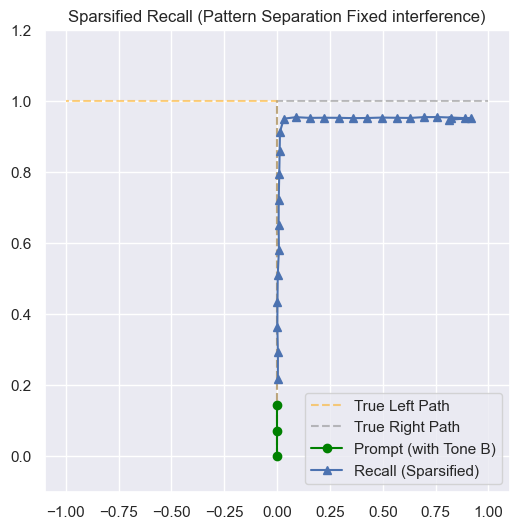

In [ ]:
from sklearn.linear_model import Ridge

# 1. Define a minimal Sparsification Layer (Dentate Gyrus)
class DentateGyrusSparsifier:
    def __init__(self, input_dim, expansion_factor=5, sparsity=0.05, seed=42):
        self.output_dim = input_dim * expansion_factor
        rng = np.random.default_rng(seed)
        # Fixed random projection matrix (Sensory -> DG)
        # We scale the weights by the input dimension to keep activations stable
        self.W_proj = rng.standard_normal((input_dim, self.output_dim)) / np.sqrt(input_dim)
        self.sparsity = sparsity
        
    def project(self, x):
        # Expand and apply nonlinearity
        activated = np.maximum(0, x @ self.W_proj)
        # Enforce sparsity (Winner-Take-All approximation)
        threshold = np.percentile(activated, (1 - self.sparsity) * 100, axis=-1, keepdims=True)
        sparse = np.where(activated >= threshold, activated, 0.0)
        # Normalize to keep values in [0, 1] range to prevent weight explosion in Delta Rule
        max_val = np.max(sparse, axis=-1, keepdims=True)
        max_val[max_val == 0] = 1.0
        return sparse / max_val

# 2. Prepare Sparsified Data
dg = DentateGyrusSparsifier(total_features, expansion_factor=5, sparsity=0.05)
sparse_left = dg.project(joint_left)
sparse_right = dg.project(joint_right)

# 3. Train Hopfield on Sparsified (Orthogonalized) Codes
# Use a LOWER learning rate for the high-dimensional sparse space
model_sparse = AsymmetricHopfieldNetwork(n_features=dg.output_dim, learning_rate=0.01)
model_sparse.fit_sequence(sparse_right, epochs=100)
model_sparse.fit_sequence(sparse_left, epochs=100)

# 4. Define a simple Linear Decoder (CA3 -> CA1/Spatial mapping)
decoder = Ridge(alpha=0.1)
decoder.fit(np.concatenate([sparse_left, sparse_right]), 
            np.concatenate([pc_left, pc_right]))

# 5. Test Recall with the same prompt (Left Cue)
model_sparse.reset_context()
sparse_prompt = dg.project(joint_right[:prompt_len])
sparse_recon = model_sparse.recall(sparse_prompt, length=seq_len - prompt_len)

# 6. Decode back to 2D
pc_recon = decoder.predict(sparse_recon)
path_recon = pc_encoder.decode(pc_recon)

# 7. Visualize Result
plt.figure(figsize=(6, 6))
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], '--', color='orange', alpha=0.5, label='True Left Path')
plt.plot(tmaze_right[:, 0], tmaze_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
plt.plot(t_left[:prompt_len, 0], t_left[:prompt_len, 1], '-o', color='green', label='Prompt (with Tone B)')
plt.plot(path_recon[:, 0], path_recon[:, 1], '-b^', label='Recall (Sparsified)')
plt.xlim(-1.1, 1.1); plt.ylim(-0.1, 1.2)
plt.title('Sparsified Recall (Pattern Separation Fixed interference)')
plt.legend(loc='lower right')
plt.show()

### 3.2. Why Clamped Context is Not Enough
Here we use the clamped context feature we just added. While explicitly separating the endogenous predicted state from the exogenous clamped context anchors the auto-regressive prediction (solving **Drift**), you will see that it does *not* solve **Catastrophic Interference**!

Because the 400 identical Place Cells mathematically dominate the 50 Tone cells in the vector, the inputs are still highly non-orthogonal. The sequential Delta Rule still overwrites the spatial weights when the Right path is trained last. This demonstrates that a simple Hopfield network cannot solve complex multimodal navigation—you **must** have a Dentate Gyrus layer to orthogonalize the inputs.

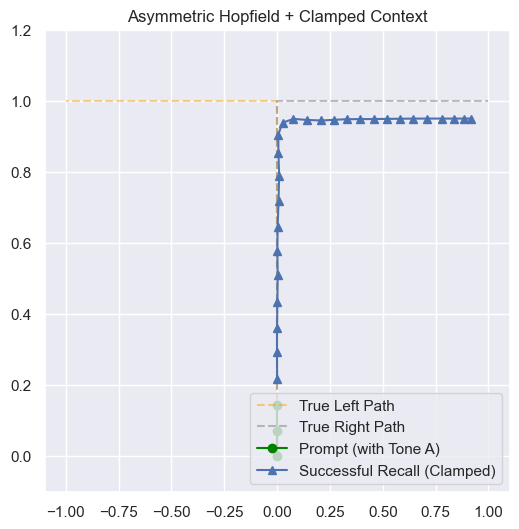

In [ ]:
# 1. Initialize Network with separated context
model_clamped = AsymmetricHopfieldNetwork(
    n_features=pc_encoder.n_cells, 
    n_context=pt_encoder.n_cells, 
    learning_rate=0.1
)

# 2. Fit sequences sequentially
model_clamped.fit_sequence(pc_left, context_data=pt_left, epochs=100)
model_clamped.fit_sequence(pc_right, context_data=pt_right, epochs=100)

# 3. Recall with clamped context (Testing LEFT path)
prompt_path_left = pc_left[:prompt_len]
model_clamped.reset_context()

recon_pc_left_clamped = model_clamped.recall(
    prompt_path_left, 
    length=seq_len - prompt_len, 
    prompt_context=pt_left[prompt_len:]
)

# 4. Decode
reconstructed_path_left_clamped = pc_encoder.decode(recon_pc_left_clamped)

# 5. Visualize Failure
prompt_path = tmaze_left[:prompt_len]

plt.figure(figsize=(6, 6))
plt.plot(tmaze_right[:, 0], tmaze_right[:, 1], '--', color='gray', alpha=0.5, label='True Right Path')
plt.plot(tmaze_left[:, 0], tmaze_left[:, 1], '--', color='orange', alpha=0.5, label='True Left Path')
plt.plot(prompt_path[:, 0], prompt_path[:, 1], '-o', color='green', label='Prompt (with Tone B)')
plt.plot(reconstructed_path_left_clamped[:, 0], reconstructed_path_left_clamped[:, 1], '-rx', label='Failed Recall (Pulled Right)')
plt.xlim(-1.1, 1.1); plt.ylim(-0.1, 1.2)
plt.title('Clamped Context without DG (Interference Persists)')
plt.legend(loc='lower right')
plt.show()